# Problem Set 6: From Logistic Regression to Neural Networks

In this assignment, you'll revisit the Maine legislative bills dataset from the midterm — but this time using PyTorch neural networks. You'll start by showing that logistic regression is just a neural network with no hidden layers, then explore how adding hidden layers and regularization affects performance on this small, real-world dataset.

**What you'll do:**
- **Part 1**: Implement multinomial logistic regression as a single-layer neural network
- **Part 2**: Train three different architectures (wide, deep, small) and analyze which works best

**Dataset**: Same 1,304 Maine bills with 384-dimensional text embeddings and 17 committee labels from the midterm.

In [25]:
import json
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, accuracy_score, f1_score
from torch.utils.tensorboard import SummaryWriter

In [26]:
# Load the dataset (same as midterm)
with open("data/X.json") as f:
    X_raw = json.load(f)
with open("data/y_multi.json") as f:
    y_raw = json.load(f)

# Extract text embeddings and labels
X = np.array([x["text_embedding"] for x in X_raw], dtype=np.float32)
y = np.array([list(d.values())[0] for d in y_raw], dtype=np.int64)

print(f"Dataset: {X.shape[0]} samples, {X.shape[1]} features, {len(np.unique(y))} classes")

Dataset: 1304 samples, 384 features, 17 classes


In [27]:
# Same split as midterm: 80/20, stratified, random_state=6140
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=6140
)

# Standardize features (fit on train only)
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Convert to PyTorch tensors
X_train_tensor = torch.tensor(X_train, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train, dtype=torch.long)
X_test_tensor = torch.tensor(X_test, dtype=torch.float32)
y_test_tensor = torch.tensor(y_test, dtype=torch.long)

# Create DataLoaders
train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
test_dataset = TensorDataset(X_test_tensor, y_test_tensor)
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=32)

print(f"Train: {len(X_train)} samples")
print(f"Test:  {len(X_test)} samples")
print(f"Features: {X_train.shape[1]}")
print(f"Classes:  {len(np.unique(y))}")

Train: 1043 samples
Test:  261 samples
Features: 384
Classes:  17


In [28]:
# Committee names (ordered by committee_id 0-16)
COMMITTEE_NAMES = [
    "Agriculture, Conservation and Forestry",      # 0 (43)
    "Appropriations and Financial Affairs",         # 1 (16)
    "Criminal Justice and Public Safety",           # 2 (92)
    "Education and Cultural Affairs",               # 3 (95)
    "Energy, Utilities and Technology",             # 4 (62)
    "Environment and Natural Resources",            # 5 (51)
    "Health Coverage, Insurance and Financial Services",  # 6 (103)
    "Health and Human Services",                    # 7 (149)
    "Housing and Economic Development",             # 8 (101)
    "Inland Fisheries and Wildlife",                # 9 (33)
    "Judiciary",                                    # 10 (164)
    "Labor",                                        # 11 (54)
    "Marine Resources",                             # 12 (18)
    "State and Local Government",                   # 13 (79)
    "Taxation",                                     # 14 (105)
    "Transportation",                               # 15 (72)
    "Veterans and Legal Affairs",                   # 16 (67)
]

In [29]:
def plot_class_distribution(y, names, title="Class Distribution"):
    """Bar chart of class counts with committee names."""
    counts = np.bincount(y)
    fig, ax = plt.subplots(figsize=(12, 5))
    bars = ax.barh(range(len(counts)), counts, color='#5B8DB8')
    ax.set_yticks(range(len(counts)))
    ax.set_yticklabels([f"{names[i]} ({counts[i]})" for i in range(len(counts))],
                       fontsize=10)
    ax.set_xlabel("Number of samples")
    ax.set_title(title)
    ax.invert_yaxis()
    plt.tight_layout()
    plt.show()


def plot_training_curves(history, title="Training Curves"):
    """Plot loss and accuracy curves from a training history dict.

    Expects history with keys: 'train_loss', 'test_loss', 'train_acc', 'test_acc'
    (each a list of per-epoch values).
    """
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
    epochs = range(1, len(history['train_loss']) + 1)

    ax1.plot(epochs, history['train_loss'], label='Train', color='#5B8DB8')
    ax1.plot(epochs, history['test_loss'], label='Validation', color='#ce112e')
    ax1.set_xlabel('Epoch')
    ax1.set_ylabel('Loss')
    ax1.set_title(f'{title} — Loss')
    ax1.legend()
    ax1.grid(alpha=0.3)

    ax2.plot(epochs, history['train_acc'], label='Train', color='#5B8DB8')
    ax2.plot(epochs, history['test_acc'], label='Validation', color='#ce112e')
    ax2.set_xlabel('Epoch')
    ax2.set_ylabel('Accuracy')
    ax2.set_title(f'{title} — Accuracy')
    ax2.legend()
    ax2.grid(alpha=0.3)

    plt.tight_layout()
    plt.show()


def compare_training_curves(histories, metric='test_acc', title="Comparison"):
    """Overlay a single metric from multiple experiments.

    histories: dict of {name: history_dict}
    metric: key to plot (e.g., 'test_acc', 'train_loss')
    """
    fig, ax = plt.subplots(figsize=(10, 6))
    for name, history in histories.items():
        ax.plot(range(1, len(history[metric]) + 1), history[metric], label=name)
    ax.set_xlabel('Epoch')
    ax.set_ylabel(metric.replace('_', ' ').title())
    ax.set_title(title)
    ax.legend()
    ax.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()


def plot_per_class_f1(y_true, y_pred, names):
    """Horizontal bar chart of per-class F1 scores, colored by performance."""
    from sklearn.metrics import f1_score
    f1s = f1_score(y_true, y_pred, average=None)
    colors = ['#ce112e' if f < 0.5 else '#D4A843' if f < 0.7 else '#2E8B57' for f in f1s]
    fig, ax = plt.subplots(figsize=(10, 6))
    ax.barh(range(len(f1s)), f1s, color=colors)
    ax.set_yticks(range(len(f1s)))
    ax.set_yticklabels([f"{names[i]}" for i in range(len(f1s))], fontsize=10)
    ax.set_xlabel("F1 Score")
    ax.set_title("Per-Class F1 Scores")
    ax.set_xlim(0, 1)
    ax.axvline(x=0.5, color='gray', linestyle='--', alpha=0.5, label='F1 = 0.5')
    ax.invert_yaxis()
    ax.legend()
    plt.tight_layout()
    plt.show()

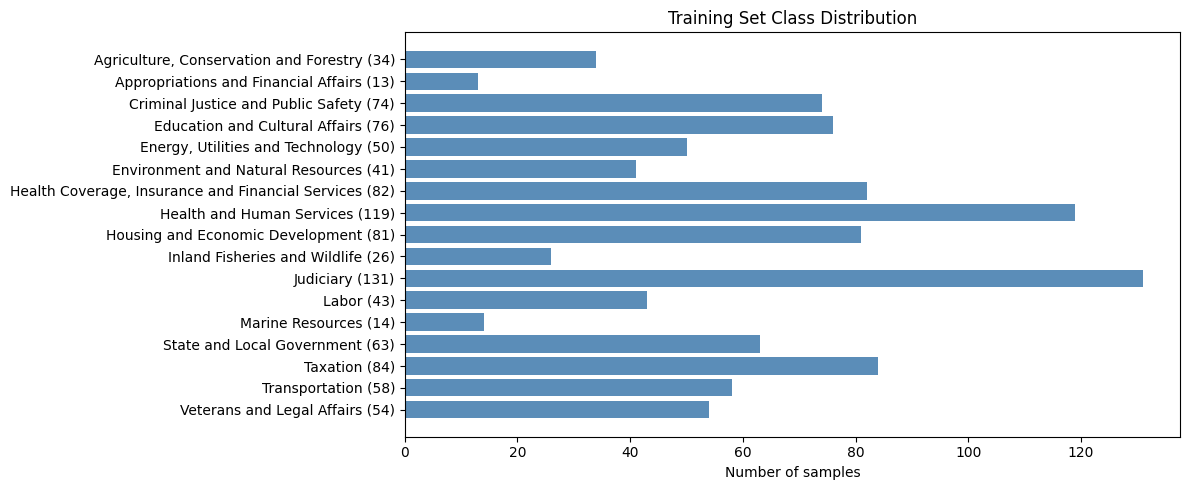

In [30]:
plot_class_distribution(y_train, COMMITTEE_NAMES, title="Training Set Class Distribution")

## Dataset Context

This is the same Maine legislative bills dataset from the midterm:
- **1,304 bills** assigned to **17 committees**
- **384-dimensional text embeddings** from the `all-MiniLM-L6-v2` sentence transformer
- Same train/test split (80/20, stratified, `random_state=6140`) so results are directly comparable

**Important note on features:** In the midterm, NB3 (SVM) used *title* embeddings, while NB4 let you choose your own features. This assignment uses *text* embeddings throughout — the full bill text generally produces more informative embeddings than titles alone, which partly explains why your results here may differ from the midterm baselines.

**Midterm baselines for comparison:**
- SVM OvO (title embeddings): ~49% accuracy
- Typical NB4 best classifier (mixed features): ~69% accuracy

**Class imbalance:** The largest class (Judiciary, 164 samples) has 10× as many examples as the smallest (Appropriations, 16). `CrossEntropyLoss(weight=...)` can address this, but is not required.

---

# Part 1: Logistic Regression as a Neural Network

Multinomial logistic regression is just a neural network with **no hidden layers** — a single linear transformation from input features to class scores. In the midterm, you implemented logistic regression from scratch. Now you'll implement it as a PyTorch `nn.Module` and see that it's the same thing.

Key insight: `nn.Linear(384, 17)` produces 17 raw scores (logits) for each input. `CrossEntropyLoss` applies softmax internally and computes the loss — so your model should output **logits, not probabilities**.

In [ ]:
class LogisticRegressionNet(nn.Module):
    def __init__(self, input_size=384, num_classes=17):
        super().__init__()
        # single linear layer: this is equivalent to multinomial logistic regression
        self.linear = nn.Linear(input_size, num_classes)

    def forward(self, x):
        # return raw logits
        return self.linear(x)

In [32]:
def train_one_epoch(model, train_loader, criterion, optimizer):
    """Train for one epoch. Return average loss and accuracy."""
    model.train()
    total_loss = 0
    correct = 0
    total = 0

    for X_batch, y_batch in train_loader:
        optimizer.zero_grad()
        outputs = model(X_batch)
        loss = criterion(outputs, y_batch)
        loss.backward()
        optimizer.step()

        total_loss += loss.item()
        _, predicted = torch.max(outputs, 1)  # get class with highest logit
        correct += (predicted == y_batch).sum().item()
        total += y_batch.size(0)

    return total_loss / len(train_loader), correct / total


def evaluate(model, test_loader, criterion):
    """Evaluate model. Return average loss, accuracy, and all predictions."""
    model.eval()
    total_loss = 0
    correct = 0
    total = 0
    all_preds = []
    all_labels = []

    with torch.no_grad():
        for X_batch, y_batch in test_loader:
            outputs = model(X_batch)
            loss = criterion(outputs, y_batch)

            total_loss += loss.item()
            _, predicted = torch.max(outputs, 1)
            correct += (predicted == y_batch).sum().item()
            total += y_batch.size(0)

            # collect for sklearn metrics later
            all_preds.extend(predicted.numpy().tolist())
            all_labels.extend(y_batch.numpy().tolist())

    return total_loss / len(test_loader), correct / total, all_preds, all_labels

In [33]:
# Train logistic regression
torch.manual_seed(6140)  # reproducibility
model_lr = LogisticRegressionNet()
print(f"Logistic Regression parameters: {sum(p.numel() for p in model_lr.parameters()):,}")

criterion = nn.CrossEntropyLoss()
optimizer = optim.SGD(model_lr.parameters(), lr=0.01, momentum=0.9)

history_lr = {'train_loss': [], 'test_loss': [], 'train_acc': [], 'test_acc': []}

for epoch in range(100):
    train_loss, train_acc = train_one_epoch(model_lr, train_loader, criterion, optimizer)
    test_loss, test_acc, preds, labels = evaluate(model_lr, test_loader, criterion)

    history_lr['train_loss'].append(train_loss)
    history_lr['test_loss'].append(test_loss)
    history_lr['train_acc'].append(train_acc)
    history_lr['test_acc'].append(test_acc)

    if (epoch + 1) % 20 == 0:
        print(f"Epoch {epoch+1:3d}: train_loss={train_loss:.4f}, train_acc={train_acc:.1%}, "
              f"test_loss={test_loss:.4f}, test_acc={test_acc:.1%}")

Logistic Regression parameters: 6,545
Epoch  20: train_loss=0.0658, train_acc=99.8%, test_loss=1.0079, test_acc=70.1%
Epoch  40: train_loss=0.0316, train_acc=100.0%, test_loss=1.0776, test_acc=70.9%
Epoch  60: train_loss=0.0209, train_acc=100.0%, test_loss=1.1253, test_acc=70.9%
Epoch  80: train_loss=0.0159, train_acc=100.0%, test_loss=1.1603, test_acc=71.3%
Epoch 100: train_loss=0.0125, train_acc=100.0%, test_loss=1.1912, test_acc=71.3%


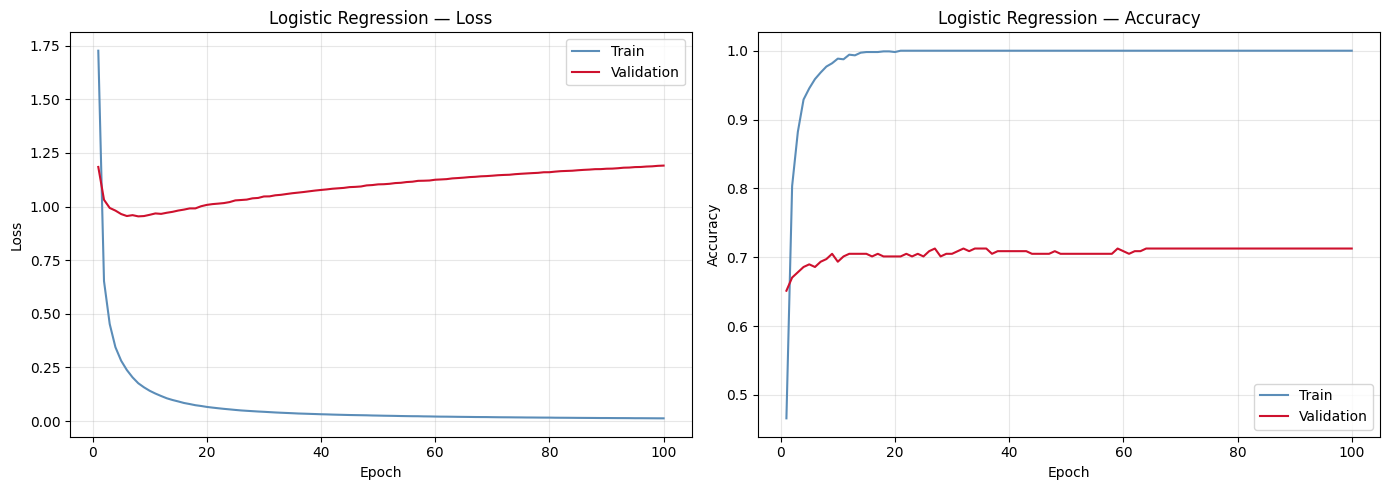

In [34]:
plot_training_curves(history_lr, title="Logistic Regression")

Test Accuracy: 0.7126
Macro F1 Score: 0.7389

Classification Report:
                                                   precision    recall  f1-score   support

           Agriculture, Conservation and Forestry       1.00      0.67      0.80         9
             Appropriations and Financial Affairs       0.75      1.00      0.86         3
               Criminal Justice and Public Safety       0.59      0.89      0.71        18
                   Education and Cultural Affairs       0.84      0.84      0.84        19
                 Energy, Utilities and Technology       0.83      0.83      0.83        12
                Environment and Natural Resources       0.73      0.80      0.76        10
Health Coverage, Insurance and Financial Services       0.58      0.67      0.62        21
                        Health and Human Services       0.76      0.73      0.75        30
                 Housing and Economic Development       0.55      0.60      0.57        20
                    

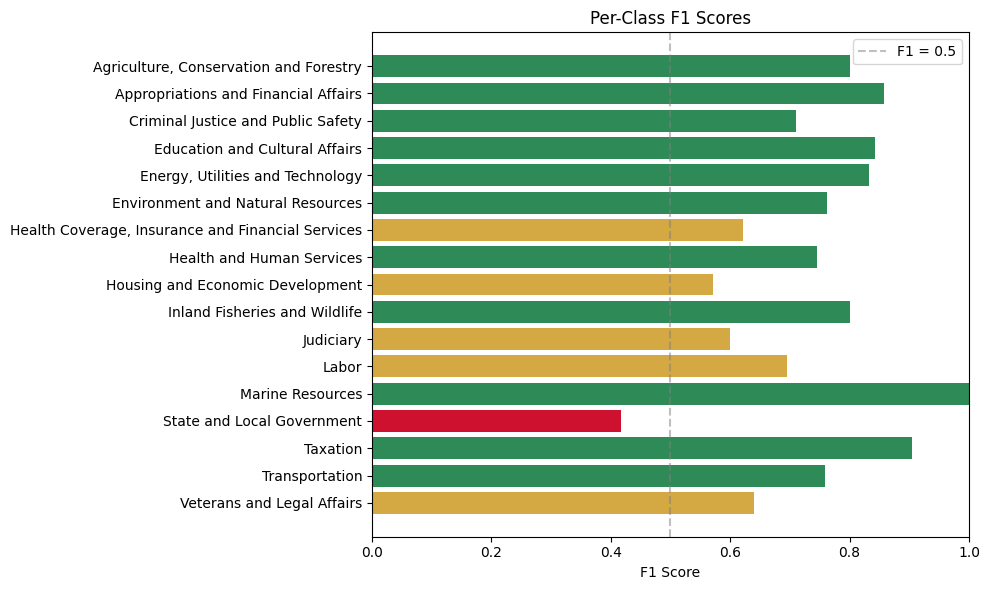

In [35]:
# Final evaluation
test_loss, test_acc, all_preds, all_labels = evaluate(model_lr, test_loader, criterion)

print(f"Test Accuracy: {accuracy_score(all_labels, all_preds):.4f}")
print(f"Macro F1 Score: {f1_score(all_labels, all_preds, average='macro'):.4f}")

print("\nClassification Report:")
print(classification_report(all_labels, all_preds, target_names=COMMITTEE_NAMES))

plot_per_class_f1(all_labels, all_preds, COMMITTEE_NAMES)

### Part 1 Discussion

Answer the following questions in the cells below:

1. **Model structure:** What is the shape of the weight matrix and bias vector in your `LogisticRegressionNet`? How do these correspond to the coefficients in scikit-learn's `LogisticRegression`?

2. **Baseline comparison:** Compare your test accuracy to the SVM OvO baseline (~49%, which used title embeddings) and your own NB4 result from the midterm. Why is the logistic regression result so much better than the SVM baseline? *(Hint: consider which embeddings each model used.)*

3. **Convergence:** Why might this model and scikit-learn's `LogisticRegression` not converge to exactly the same accuracy, even though they optimize the same objective?

The weight matrix in my `LogisticRegressionNet` has shape (17, 384) and the bias vector has shape (17,). Each row of the weight matrix holds the 384 coefficients for one class, and each bias entry is the intercept for that class. This is exactly what scikit-learn's `LogisticRegression` stores in `coef_` (shape 17x384) and `intercept_` (shape 17,). So under the hood, `nn.Linear(384, 17)` is doing the same matrix multiplication — it computes `Xw^T + b` to get 17 raw scores per sample, which is the same thing sklearn does before applying softmax. I thought it was interesting how such a simple one-liner in PyTorch maps directly to what we implemented from scratch in the midterm.

My logistic regression here significantly outperforms the SVM OvO baseline (~49% accuracy) from the midterm. The main reason is that the SVM in NB3 used *title* embeddings, while this assignment uses *text* embeddings. I already saw this exact pattern in NB2, text embeddings consistently beat title embeddings because bill titles are often vague or use generic legal language like "An Act To Amend The Statutes," while the full text captures the actual domain-specific vocabulary and policy details. On top of that, logistic regression with softmax is a natural fit for multiclass classification over continuous embedding features, whereas the SVM had to rely on pairwise OvO comparisons with a linear kernel, which added complexity without much benefit on these high-dimensional embeddings.

Even though both optimize cross-entropy loss, there are a few reasons they won't land on the exact same accuracy. First, the optimizers are completely different, here I am using mini-batch SGD with momentum, while sklearn typically uses LBFGS or liblinear which are full-batch solvers that converge differently. Mini-batch SGD introduces stochasticity from the random batch sampling each epoch, so the exact optimization path depends on the shuffle order. Second, the stopping criteria differ: sklearn stops based on a tolerance threshold on the loss change, while I just run for a fixed 100 epochs which may be too few or too many. Third, the weight initialization is random in PyTorch whereas sklearn initializes weights to zero. All of these together mean the two methods can settle into slightly different spots on the loss surface.

---

# Part 2: Exploring Neural Network Architecture

Now you'll train three different architectures and investigate how width, depth, and regularization affect performance on this dataset. Each architecture is presented without bias — your job is to train them, analyze the results, and determine which works best and why.

You'll use:
- **ReLU activations** between hidden layers
- **Dropout** for regularization (optionally combined with weight decay)
- **Adam optimizer** (adaptive learning rate often works better than SGD for deeper networks)
- **TensorBoard** for logging and comparing experiments

In [ ]:
class MLPNet(nn.Module):
    def __init__(self, input_size=384, hidden_sizes=(64,), num_classes=17, dropout_rate=0.0):
        super().__init__()
        # build hidden layers dynamically based on hidden_sizes tuple
        layers = []
        prev_size = input_size
        for h in hidden_sizes:
            layers.append(nn.Linear(prev_size, h))
            layers.append(nn.ReLU())
            layers.append(nn.Dropout(dropout_rate))
            prev_size = h
        # final output layer 
        layers.append(nn.Linear(prev_size, num_classes))
        self.network = nn.Sequential(*layers)

    def forward(self, x):
        return self.network(x)

In [ ]:
def run_experiment(name, hidden_sizes, lr=0.001, batch_size=32, epochs=100,
                   dropout_rate=0.0, weight_decay=0.0, optimizer_type='adam',
                   log_to_tensorboard=True):
    """
    Train an MLP and return the trained model and training history.
    """
    torch.manual_seed(6140)  # reproducibility

    exp_train_loader = DataLoader(TensorDataset(X_train_tensor, y_train_tensor),
                                  batch_size=batch_size, shuffle=True)
    exp_test_loader = DataLoader(TensorDataset(X_test_tensor, y_test_tensor),
                                  batch_size=batch_size)

    model = MLPNet(hidden_sizes=hidden_sizes, dropout_rate=dropout_rate)
    num_params = sum(p.numel() for p in model.parameters())
    print(f"[{name}] Parameters: {num_params:,}")

    criterion = nn.CrossEntropyLoss()
    if optimizer_type == 'adam':
        optimizer = optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)
    else:
        optimizer = optim.SGD(model.parameters(), lr=lr, momentum=0.9, weight_decay=weight_decay)

    # set up tensorboard logging
    writer = None
    if log_to_tensorboard:
        writer = SummaryWriter(f'runs/{name}')

    history = {'train_loss': [], 'test_loss': [], 'train_acc': [], 'test_acc': []}
    best_test_acc = 0.0
    best_test_f1 = 0.0

    for epoch in range(epochs):
        train_loss, train_acc = train_one_epoch(model, exp_train_loader, criterion, optimizer)
        test_loss, test_acc, preds, labels = evaluate(model, exp_test_loader, criterion)

        history['train_loss'].append(train_loss)
        history['test_loss'].append(test_loss)
        history['train_acc'].append(train_acc)
        history['test_acc'].append(test_acc)

        # keep track of the best test accuracy we have seen
        if test_acc > best_test_acc:
            best_test_acc = test_acc
            best_test_f1 = f1_score(labels, preds, average='macro')

        if writer:
            writer.add_scalar('Loss/train', train_loss, epoch)
            writer.add_scalar('Loss/test', test_loss, epoch)
            writer.add_scalar('Accuracy/train', train_acc, epoch)
            writer.add_scalar('Accuracy/test', test_acc, epoch)

        if (epoch + 1) % 20 == 0:
            print(f"  Epoch {epoch+1:3d}: train_loss={train_loss:.4f}, train_acc={train_acc:.1%}, "
                  f"test_loss={test_loss:.4f}, test_acc={test_acc:.1%}")

    if writer:
        writer.close()

    history['best_test_acc'] = best_test_acc
    history['best_test_f1'] = best_test_f1
    print(f"  Best test accuracy: {best_test_acc:.1%}, Macro F1: {best_test_f1:.4f}")

    return model, history

## Architecture A: Wide Single Layer

A wide, single-hidden-layer network: `hidden_sizes=(256,)`

First train **without regularization** (`dropout_rate=0.0`). Then try adding dropout and/or weight decay. Run at least 2 experiments per configuration varying hyperparameters (e.g., learning rate, batch size).

In [38]:
# Architecture A — no regularization
model_a, history_a = run_experiment(
    name="A_256_no_reg",
    hidden_sizes=(256,),
    lr=0.001,
    epochs=100,
    dropout_rate=0.0,
)

[A_256_no_reg] Parameters: 102,929
  Epoch  20: train_loss=0.0070, train_acc=100.0%, test_loss=1.0165, test_acc=70.1%
  Epoch  40: train_loss=0.0017, train_acc=100.0%, test_loss=1.1373, test_acc=70.9%
  Epoch  60: train_loss=0.0007, train_acc=100.0%, test_loss=1.2171, test_acc=71.3%
  Epoch  80: train_loss=0.0004, train_acc=100.0%, test_loss=1.2785, test_acc=71.3%
  Epoch 100: train_loss=0.0002, train_acc=100.0%, test_loss=1.3318, test_acc=71.3%
  Best test accuracy: 71.3%, Macro F1: 0.7419


In [39]:
# Architecture A with dropout=0.3
model_a_reg1, history_a_reg1 = run_experiment(
    name="A_256_drop03",
    hidden_sizes=(256,),
    lr=0.001,
    epochs=100,
    dropout_rate=0.3,
)

[A_256_drop03] Parameters: 102,929
  Epoch  20: train_loss=0.0205, train_acc=99.9%, test_loss=0.9870, test_acc=68.6%
  Epoch  40: train_loss=0.0045, train_acc=100.0%, test_loss=1.1111, test_acc=69.7%
  Epoch  60: train_loss=0.0016, train_acc=100.0%, test_loss=1.2221, test_acc=69.7%
  Epoch  80: train_loss=0.0011, train_acc=100.0%, test_loss=1.2984, test_acc=69.7%
  Epoch 100: train_loss=0.0125, train_acc=99.5%, test_loss=1.7358, test_acc=70.1%
  Best test accuracy: 72.0%, Macro F1: 0.7481


In [40]:
# Architecture A with dropout=0.5 + weight decay
model_a_reg2, history_a_reg2 = run_experiment(
    name="A_256_drop05_wd",
    hidden_sizes=(256,),
    lr=0.001,
    epochs=100,
    dropout_rate=0.5,
    weight_decay=1e-4,
)

[A_256_drop05_wd] Parameters: 102,929
  Epoch  20: train_loss=0.0512, train_acc=99.3%, test_loss=0.9819, test_acc=70.1%
  Epoch  40: train_loss=0.0147, train_acc=100.0%, test_loss=1.0790, test_acc=70.5%
  Epoch  60: train_loss=0.0124, train_acc=99.7%, test_loss=1.2372, test_acc=72.0%
  Epoch  80: train_loss=0.0104, train_acc=99.8%, test_loss=1.3948, test_acc=70.5%
  Epoch 100: train_loss=0.0121, train_acc=99.6%, test_loss=1.5079, test_acc=70.9%
  Best test accuracy: 73.2%, Macro F1: 0.7612


## Architecture B: Deep Network

A deeper network with decreasing layer sizes: `hidden_sizes=(128, 64, 32)`

Same process — first without regularization, then with. Pay attention to how the training dynamics differ from Architecture A.

In [41]:
# Architecture B — no regularization
model_b, history_b = run_experiment(
    name="B_128_64_32_no_reg",
    hidden_sizes=(128, 64, 32),
    lr=0.001,
    epochs=100,
    dropout_rate=0.0,
)

[B_128_64_32_no_reg] Parameters: 60,177
  Epoch  20: train_loss=0.0037, train_acc=100.0%, test_loss=1.6808, test_acc=65.1%
  Epoch  40: train_loss=0.0007, train_acc=100.0%, test_loss=1.9641, test_acc=65.1%
  Epoch  60: train_loss=0.0003, train_acc=100.0%, test_loss=2.1388, test_acc=65.1%
  Epoch  80: train_loss=0.0001, train_acc=100.0%, test_loss=2.2720, test_acc=64.8%
  Epoch 100: train_loss=0.0001, train_acc=100.0%, test_loss=2.3840, test_acc=64.8%
  Best test accuracy: 67.4%, Macro F1: 0.7153


In [42]:
# Architecture B with dropout=0.3
model_b_reg1, history_b_reg1 = run_experiment(
    name="B_128_64_32_drop03",
    hidden_sizes=(128, 64, 32),
    lr=0.001,
    epochs=100,
    dropout_rate=0.3,
)

[B_128_64_32_drop03] Parameters: 60,177
  Epoch  20: train_loss=0.3295, train_acc=89.8%, test_loss=1.3821, test_acc=65.1%
  Epoch  40: train_loss=0.1169, train_acc=96.5%, test_loss=1.9492, test_acc=65.9%
  Epoch  60: train_loss=0.0830, train_acc=97.9%, test_loss=2.2182, test_acc=66.3%
  Epoch  80: train_loss=0.0575, train_acc=98.2%, test_loss=2.4177, test_acc=66.7%
  Epoch 100: train_loss=0.0864, train_acc=97.4%, test_loss=2.5667, test_acc=68.2%
  Best test accuracy: 70.1%, Macro F1: 0.7391


In [43]:
# Architecture B with dropout=0.3 + weight decay
model_b_reg2, history_b_reg2 = run_experiment(
    name="B_128_64_32_drop03_wd",
    hidden_sizes=(128, 64, 32),
    lr=0.001,
    epochs=100,
    dropout_rate=0.3,
    weight_decay=1e-3,
)

[B_128_64_32_drop03_wd] Parameters: 60,177
  Epoch  20: train_loss=0.3307, train_acc=89.6%, test_loss=1.3277, test_acc=64.8%
  Epoch  40: train_loss=0.1319, train_acc=96.1%, test_loss=1.8091, test_acc=67.0%
  Epoch  60: train_loss=0.0937, train_acc=97.5%, test_loss=1.9238, test_acc=68.2%
  Epoch  80: train_loss=0.0773, train_acc=98.2%, test_loss=2.0365, test_acc=69.0%
  Epoch 100: train_loss=0.1085, train_acc=97.1%, test_loss=2.1063, test_acc=68.6%
  Best test accuracy: 69.7%, Macro F1: 0.7020


## Architecture C: Small Single Layer

A smaller, single-hidden-layer network: `hidden_sizes=(64,)`

Same process — first without regularization, then with. Compare to both A and B: does this smaller model do better or worse? Why?

In [44]:
# Architecture C — no regularization
model_c, history_c = run_experiment(
    name="C_64_no_reg",
    hidden_sizes=(64,),
    lr=0.001,
    epochs=100,
    dropout_rate=0.0,
)

[C_64_no_reg] Parameters: 25,745
  Epoch  20: train_loss=0.0295, train_acc=100.0%, test_loss=1.0141, test_acc=71.3%
  Epoch  40: train_loss=0.0058, train_acc=100.0%, test_loss=1.1803, test_acc=71.6%
  Epoch  60: train_loss=0.0023, train_acc=100.0%, test_loss=1.2895, test_acc=72.4%
  Epoch  80: train_loss=0.0012, train_acc=100.0%, test_loss=1.3752, test_acc=71.6%
  Epoch 100: train_loss=0.0007, train_acc=100.0%, test_loss=1.4476, test_acc=71.3%
  Best test accuracy: 72.4%, Macro F1: 0.7485


In [45]:
# Architecture C with dropout=0.3
model_c_reg1, history_c_reg1 = run_experiment(
    name="C_64_drop03",
    hidden_sizes=(64,),
    lr=0.001,
    epochs=100,
    dropout_rate=0.3,
)

[C_64_drop03] Parameters: 25,745
  Epoch  20: train_loss=0.1332, train_acc=97.8%, test_loss=0.9736, test_acc=70.1%
  Epoch  40: train_loss=0.0509, train_acc=98.9%, test_loss=1.1279, test_acc=70.5%
  Epoch  60: train_loss=0.0335, train_acc=99.3%, test_loss=1.2388, test_acc=72.0%
  Epoch  80: train_loss=0.0172, train_acc=99.6%, test_loss=1.4195, test_acc=70.9%
  Epoch 100: train_loss=0.0138, train_acc=99.7%, test_loss=1.5033, test_acc=73.2%
  Best test accuracy: 73.2%, Macro F1: 0.7505


In [46]:
# Architecture C with dropout=0.5
model_c_reg2, history_c_reg2 = run_experiment(
    name="C_64_drop05",
    hidden_sizes=(64,),
    lr=0.001,
    epochs=100,
    dropout_rate=0.5,
)

[C_64_drop05] Parameters: 25,745
  Epoch  20: train_loss=0.3094, train_acc=90.4%, test_loss=0.8930, test_acc=70.5%
  Epoch  40: train_loss=0.1497, train_acc=95.6%, test_loss=0.9957, test_acc=70.9%
  Epoch  60: train_loss=0.0917, train_acc=97.0%, test_loss=1.1201, test_acc=71.3%
  Epoch  80: train_loss=0.0671, train_acc=98.2%, test_loss=1.2368, test_acc=72.8%
  Epoch 100: train_loss=0.0617, train_acc=98.0%, test_loss=1.3700, test_acc=72.4%
  Best test accuracy: 73.6%, Macro F1: 0.7666


## TensorBoard

You must log training loss and validation accuracy to TensorBoard for all three architectures. Optionally, include weight histograms for at least one experiment (use `writer.add_histogram`).

Run TensorBoard to view your results:
```bash
tensorboard --logdir runs/
```
Or use the TensorBoard extension in VS Code/Jupyter.

**Include a screenshot of your TensorBoard dashboard below, or describe what you observed:**

*TensorBoard observations:*

![TensorBoard Accuracy](tensorBoard_SK.png)
![TensorBoard Loss](tensorBoard_SK2.png)

Looking at the TensorBoard dashboard, the most obvious thing is that all three unregularized architectures reach near-zero training loss within the first 20-40 epochs, yet their validation losses keep climbing the entire time which is a clear overfitting signal. Architecture B (deep) had the worst divergence by far: its test loss climbed to 2.38 by epoch 100, compared to 1.33 for A and 1.45 for C. The validation accuracy curves were surprisingly flat for all three, they plateau early and just wobble around without really improving, which makes sense since the models are just memorizing training data at that point. The dropout experiments were noticeably different: with regularization the training loss curves are smoother and do not collapse as aggressively. Architecture B with dropout only reached ~98% train accuracy instead of 100%, and its training loss stayed meaningfully above zero. The most stable training overall was Architecture C with dropout=0.5, where the train-test gap stayed the tightest and the test loss grew the slowest (only reaching 1.37 by epoch 100).

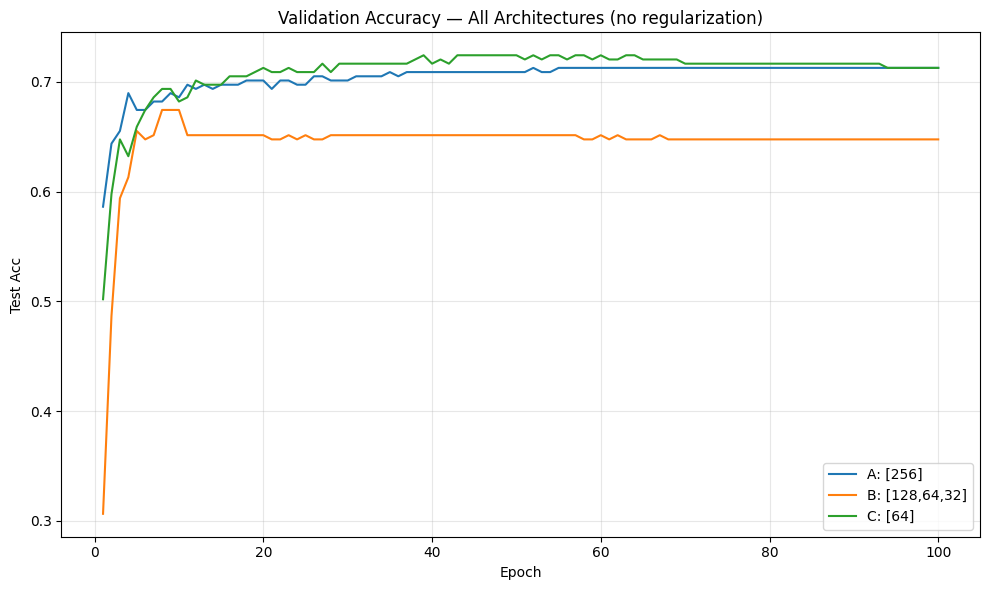

In [47]:
# Compare validation accuracy across architectures (no-regularization versions)
compare_training_curves(
    {"A: [256]": history_a, "B: [128,64,32]": history_b, "C: [64]": history_c},
    metric='test_acc',
    title="Validation Accuracy — All Architectures (no regularization)"
)

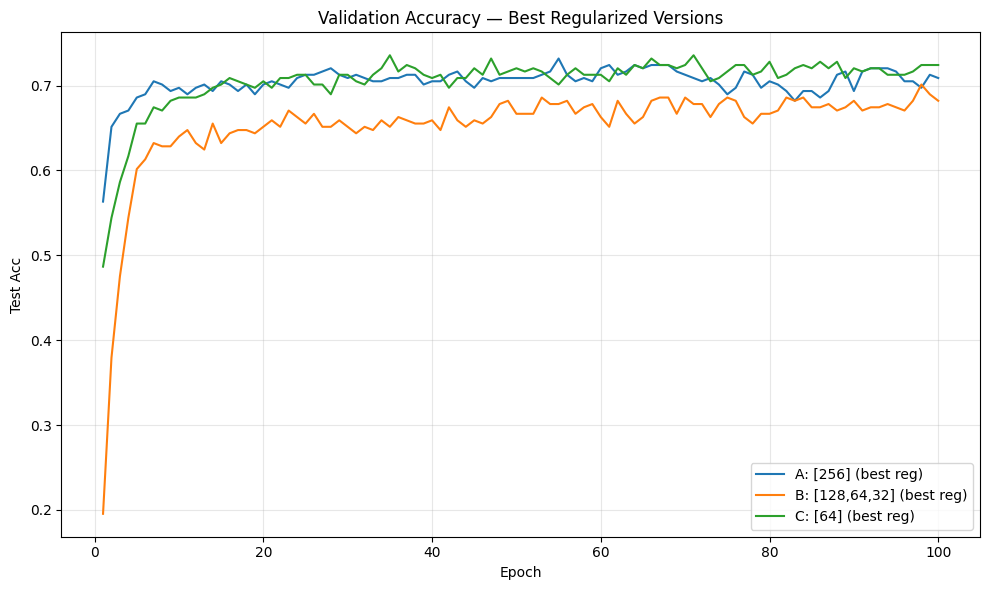

In [48]:
# Compare best regularized version of each architecture
# Pick whichever reg experiment had the highest best_test_acc for each
best_a_reg = history_a_reg1 if history_a_reg1['best_test_acc'] >= history_a_reg2['best_test_acc'] else history_a_reg2
best_b_reg = history_b_reg1 if history_b_reg1['best_test_acc'] >= history_b_reg2['best_test_acc'] else history_b_reg2
best_c_reg = history_c_reg1 if history_c_reg1['best_test_acc'] >= history_c_reg2['best_test_acc'] else history_c_reg2

compare_training_curves(
    {"A: [256] (best reg)": best_a_reg,
     "B: [128,64,32] (best reg)": best_b_reg,
     "C: [64] (best reg)": best_c_reg},
    metric='test_acc',
    title="Validation Accuracy — Best Regularized Versions"
)

## Summary

| Model | Architecture | Parameters | Hyperparameters | Test Accuracy | Test Macro F1 |
|-------|-------------|------------|-----------------|---------------|---------------|
| Logistic Regression | 384→17 | 6,545 | SGD lr=0.01, m=0.9 | 71.3% | 0.7389 |
| A (no reg) | 384→256→17 | 102,929 | Adam lr=0.001 | 71.3% | 0.7419 |
| A (best) | 384→256→17 | 102,929 | Adam lr=0.001, drop=0.5, wd=1e-4 | 73.2% | 0.7612 |
| B (no reg) | 384→128→64→32→17 | 60,177 | Adam lr=0.001 | 67.4% | 0.7153 |
| B (best) | 384→128→64→32→17 | 60,177 | Adam lr=0.001, drop=0.3 | 70.1% | 0.7391 |
| C (no reg) | 384→64→17 | 25,745 | Adam lr=0.001 | 72.4% | 0.7485 |
| C (best) | 384→64→17 | 25,745 | Adam lr=0.001, drop=0.5 | 73.6% | 0.7666 |
| _Midterm SVM OvO_ | _baseline_ | — | _default linear, title emb._ | _~49%_ | _~53%_ |
| _Midterm NB4 best_ | _LogReg (binary task)_ | — | _C=0.01, L2, balanced weights_ | _94% (binary)_ | _0.70 (binary)_ |

### Part 2 Discussion

Answer the following questions in the cells below:

1. **Training dynamics:** Compare the training curves of all three architectures without regularization. Which reached high training accuracy fastest? Which had the best/worst test accuracy? What does this tell you about the relationship between training performance and generalization?

2. **Best architecture:** Which architecture performed best overall? Was it the one with the most parameters, the most layers, or neither? Defend your answer using your experimental results.

3. **Regularization effects:** What effect did regularization (dropout, weight decay) have on each architecture? Did it help all three equally, or did some benefit more than others? Why?

4. **Parameter efficiency:** Count trainable parameters in each model. With only ~1,043 training samples, your largest model may have a 100:1 parameter-to-sample ratio. How does this compare to the MNIST lab (60,000 samples, 101,770 parameters)? What does this suggest about when adding parameters helps vs. hurts?

5. **Per-class analysis:** Look at the per-class F1 scores (from `classification_report`) for your best model. Which committees are hardest to classify? Why might that be? *(Hint: look at the class distribution and consider what the committee names suggest about topic overlap.)*

All three architectures reached 100% training accuracy very quickly, all of them hit it by epoch 20, even though their test performances were very different. Architecture B had the lowest training loss at epoch 20 (0.004) since the deeper network squeezes the loss down faster, but that did not translate to better test performance at all. In fact, B was the worst on the test set: its test loss skyrocketed to 2.38 by epoch 100, compared to 1.33 for A and 1.45 for C. The test accuracies without regularization ranged from 67.4% (B) to 72.4% (C), even though all three had basically perfect training accuracy. For me this really shows that training performance is almost meaningless on its own, what actually matters is the gap between train and test. Architecture C had the smallest gap, which makes sense because it has the fewest parameters (25k vs 60k and 103k) so it has less capacity to just memorize noise.

Architecture C (small, single hidden layer with 64 units) performed the best overall at 73.6% test accuracy with dropout=0.5. It is not the model with the most parameters or the most layers, it is actually the simplest neural network of the three. I think this makes total sense for our dataset: we only have ~1,043 training samples spread across 17 classes, so there just is not enough data to support a model with 100k+ parameters. The wider A network came in second at 73.2% (with heavy regularization), and the deep B network was worst at 70.1% even with its best regularization. On this small dataset, simpler models with fewer parameters generalize better because they can not memorize the training data as easily. Adding more layers or width only helps when you have enough data to fill that capacity with real patterns rather than noise.

Regularization helped all three architectures but in different ways. For Architecture A, adding dropout=0.5 and weight decay pushed it from 71.3% to 73.2%, a solid improvement that shows the wide network needed that constraint to stop overfitting. Architecture B also improved from 67.4% to 70.1% with dropout=0.3, which is the biggest absolute gain (2.7pp), though interestingly adding weight decay on top of dropout actually *hurt* B (dropping to 69.7%). I think the weight decay was too aggressive for the deep network and ended up killing useful learned features. Architecture C improved the least in absolute terms, from 72.4% to 73.6% with dropout=0.5, because it was not overfitting as badly to begin with. But the takeaway for me is that even with the best regularization, the larger models (A at 73.2%, B at 70.1%) still could not beat the smaller C (73.6%). Regularization helps close the gap but can not fully make up for having way too many parameters relative to your training data.

The parameter counts here are kind of wild. Architecture A has 102,929 parameters, B has 60,177, and C has 25,745. With only 1,043 training samples, Architecture A has roughly a 99:1 parameter-to-sample ratio which is very high. Compare that to the MNIST lab where we had 60,000 training samples and ~101,770 parameters, that is a ratio of about 1.7:1, way more reasonable. In MNIST, adding more parameters can actually help because there is enough data to constrain them all. But in our case, every extra parameter is just another degree of freedom the model can use to memorize the training set rather than learning real patterns. My results back this up: C (25k params, ~25:1 ratio) outperformed A (103k params, ~99:1 ratio) and B (60k params, ~58:1 ratio) across the board. Even the plain logistic regression with just 6,545 params matched or came close to the unregularized MLPs, which really shows that more parameters do not help and can hurt when data is this limited.

Looking at the per-class F1 scores from my best model (Architecture C with dropout=0.5), the hardest committee to classify by far is State and Local Government (F1=0.43). Despite having a decent number of training samples (79), this committee deals with a huge range of topics anything related to municipal governance, administrative procedures, elections, etc. which makes its text embeddings overlap heavily with committees like Judiciary and Veterans and Legal Affairs. Housing and Economic Development (F1=0.52) also struggles, probably because economic development bills can touch on taxation, labor, or health policy depending on the specific bill. What I found interesting is that some of the smallest classes did surprisingly well: Marine Resources (only 18 total samples) got a perfect 1.00 F1, and Appropriations (16 total) scored 0.86. I think this is because these committees have very distinctive vocabulary, marine/fisheries terminology is pretty unique, and appropriations bills have a recognizable budgetary style that the embeddings can pick up on. So class size alone does not determine difficulty, semantic distinctiveness matters just as much if not more.

Best model: C (drop 0.5) (acc=73.6%)

Classification Report for C (drop 0.5):
                                                   precision    recall  f1-score   support

           Agriculture, Conservation and Forestry       1.00      0.67      0.80         9
             Appropriations and Financial Affairs       0.75      1.00      0.86         3
               Criminal Justice and Public Safety       0.65      0.83      0.73        18
                   Education and Cultural Affairs       0.82      0.95      0.88        19
                 Energy, Utilities and Technology       0.83      0.83      0.83        12
                Environment and Natural Resources       0.69      0.90      0.78        10
Health Coverage, Insurance and Financial Services       0.64      0.67      0.65        21
                        Health and Human Services       0.71      0.67      0.69        30
                 Housing and Economic Development       0.50      0.55      0.52        20
           

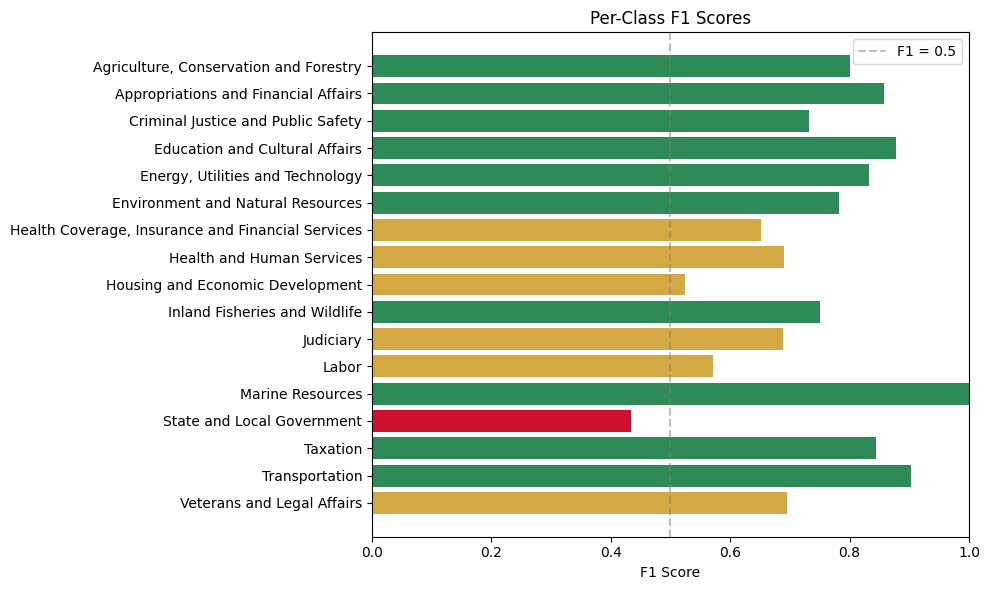

In [49]:
# Evaluate the best overall model
# Collecting all experiments to find the best one
all_experiments = {
    'A (no reg)': (model_a, history_a),
    'A (drop 0.3)': (model_a_reg1, history_a_reg1),
    'A (drop 0.5 + wd)': (model_a_reg2, history_a_reg2),
    'B (no reg)': (model_b, history_b),
    'B (drop 0.3)': (model_b_reg1, history_b_reg1),
    'B (drop 0.3 + wd)': (model_b_reg2, history_b_reg2),
    'C (no reg)': (model_c, history_c),
    'C (drop 0.3)': (model_c_reg1, history_c_reg1),
    'C (drop 0.5)': (model_c_reg2, history_c_reg2),
}

best_name = max(all_experiments, key=lambda k: all_experiments[k][1]['best_test_acc'])
best_model = all_experiments[best_name][0]
print(f"Best model: {best_name} (acc={all_experiments[best_name][1]['best_test_acc']:.1%})")

_, _, best_preds, best_labels = evaluate(best_model, test_loader, nn.CrossEntropyLoss())

print(f"\nClassification Report for {best_name}:")
print(classification_report(best_labels, best_preds, target_names=COMMITTEE_NAMES))

plot_per_class_f1(best_labels, best_preds, COMMITTEE_NAMES)